In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import datetime as dt
import seaborn as sns
import numpy as np
from mlxtend.frequent_patterns import association_rules, apriori
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
import warnings
warnings.filterwarnings("ignore")

In [2]:
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:   
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv("hm_analysis.csv")

In [ ]:
df

,t_dat,customer_id,price,age,Active,FN,club_member_status,age_group,article_id,prod_name,product_group_name,section_name,garment_group_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,29.99,24,0,0,ACTIVE,20대,663713001,Atlanta Push Body Harlow,Underwear,Womens Lingerie,"Under-, Nightwear"
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,17.99,24,0,0,ACTIVE,20대,541518023,Rae Push (Melbourne) 2p,Underwear,Womens Lingerie,"Under-, Nightwear"
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,8.99,32,1,1,ACTIVE,30대,505221004,Inca Jumper,Garment Upper body,Divided Selected,Knitwear
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,9.99,32,1,1,ACTIVE,30대,685687003,W YODA KNIT OL OFFER,Garment Upper body,Womens Everyday Collection,Special Offers
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,9.99,32,1,1,ACTIVE,30대,685687004,W YODA KNIT OL OFFER,Garment Upper body,Womens Everyday Collection,Special Offers


In [80]:
df.info() # date type이 바뀜

<class 'pandas.DataFrame'>
RangeIndex: 31648066 entries, 0 to 31648065
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   t_dat               str    
 1   customer_id         str    
 2   price               float64
 3   age                 int64  
 4   Active              int64  
 5   FN                  int64  
 6   club_member_status  str    
 7   age_group           str    
 8   article_id          int64  
 9   prod_name           str    
 10  product_group_name  str    
 11  section_name        str    
 12  garment_group_name  str    
dtypes: float64(1), int64(4), str(8)
memory usage: 7.4 GB


In [81]:
df['t_dat'] = pd.to_datetime(df['t_dat']) # 수정

## RFM 지표

In [82]:
# 1. RFM 지표 계산
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

# 2. 확인
print(rfm.head())

                                         customer_id  Recency  Frequency  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       18         10   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...       77         23   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...        8          7   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...      472          1   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...       42          6   

   Monetary  
0    382.90  
1   1535.14  
2    415.82  
3     35.98  
4    277.12  


#### 4분위수로 확인

In [83]:
quantiles = [0.25, 0.5, 0.75]

# 1. 각 지표별 경계값(Quantile) 계산
# .quantile() 함수를 사용하면 해당 백분율에 위치한 실제 값을 바로 찾아줍니다.
rfm_thresholds = rfm[['Recency', 'Frequency', 'Monetary']].quantile(quantiles)

# 2. 결과 출력
print("📊 RFM 지표별 4분위수 경계값")
print("-" * 45)
print(rfm_thresholds)

📊 RFM 지표별 4분위수 경계값
---------------------------------------------
      Recency  Frequency  Monetary
0.25     49.0        1.0     52.94
0.50    150.0        3.0    145.96
0.75    395.0        8.0    417.63


#### 5분위수로 확인

In [84]:
quantiles = [0.2, 0.4, 0.6, 0.8]

# 1. 각 지표별 경계값(Quantile) 계산
# .quantile() 함수를 사용하면 해당 백분율에 위치한 실제 값을 바로 찾아줍니다.
rfm_thresholds = rfm[['Recency', 'Frequency', 'Monetary']].quantile(quantiles)

# 2. 결과 출력
print("📊 RFM 지표별 5분위수 경계값")
print("-" * 45)
print(rfm_thresholds)

📊 RFM 지표별 5분위수 경계값
---------------------------------------------
     Recency  Frequency  Monetary
0.2     35.0        1.0    40.960
0.4     95.0        2.0    97.960
0.6    229.0        4.0   218.870
0.8    458.0       10.0   531.332


## RFM 분포 시각화

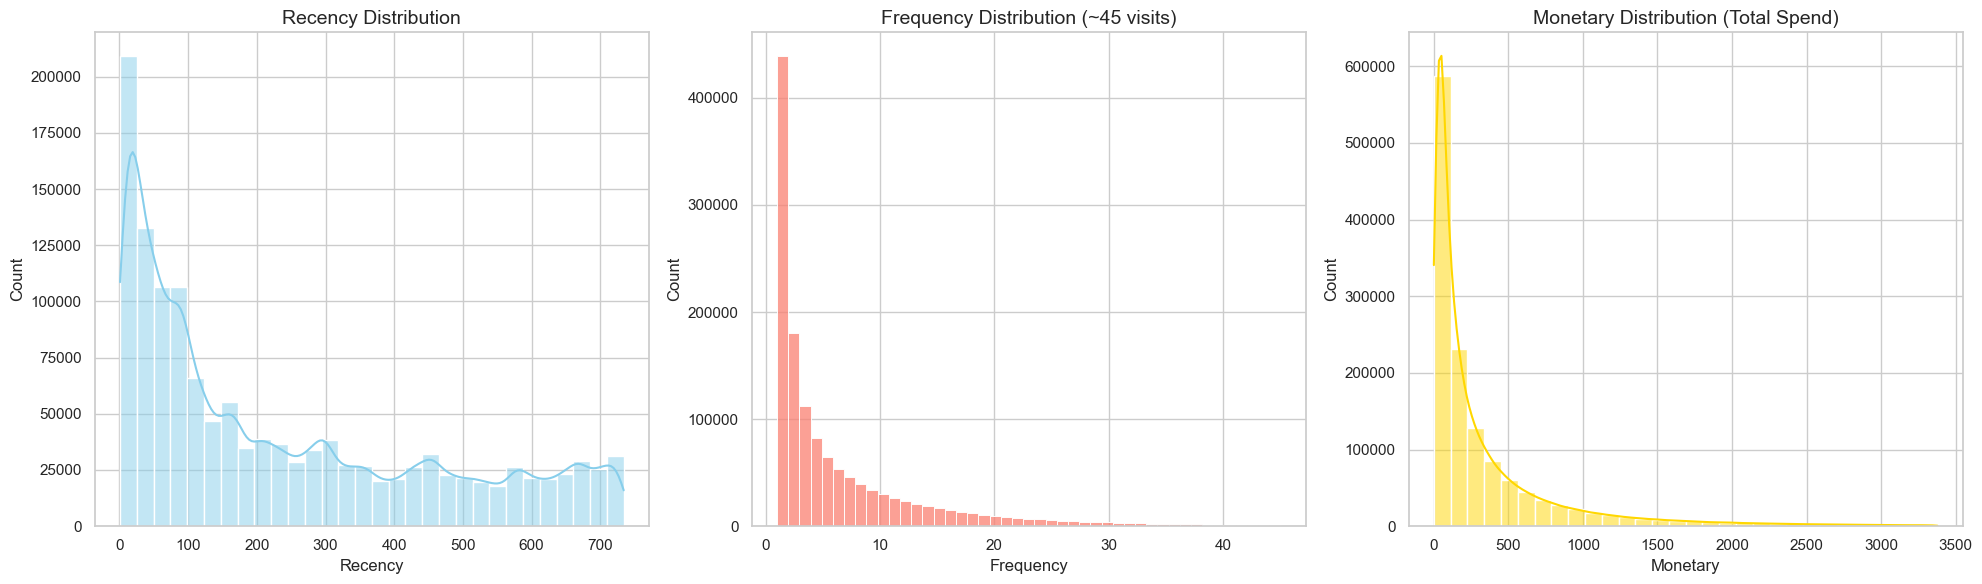

In [85]:
# 시각화 (이제 rfm 변수를 사용하여 히스토그램을 그립니다)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Recency
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution', fontsize=14)

# Frequency (상위 1% 제외하고 시각화하여 분포 파악 용이하게 설정)
f_limit = rfm['Frequency'].quantile(0.99)
sns.histplot(rfm[rfm['Frequency'] <= f_limit]['Frequency'], bins=int(f_limit), kde=False, ax=axes[1], color='salmon')
axes[1].set_title(f'Frequency Distribution (~{int(f_limit)} visits)', fontsize=14)

# Monetary (상위 1% 제외)
m_limit = rfm['Monetary'].quantile(0.99)
sns.histplot(rfm[rfm['Monetary'] <= m_limit]['Monetary'], bins=30, kde=True, ax=axes[2], color='gold')
axes[2].set_title(f'Monetary Distribution (Total Spend)', fontsize=14)

plt.tight_layout()
plt.show()

## 5분위수로 세그먼트 나누기

In [86]:
# 1. 각 지표별로 백분율 순위(Percentile Rank) 계산
# pct=True 옵션은 0(최하위) ~ 1(최상위) 사이의 값을 반환합니다.
rfm['R_pct'] = rfm['Recency'].rank(pct=True, ascending=False) # Recency는 작을수록 좋으므로 내림차순
rfm['F_pct'] = rfm['Frequency'].rank(pct=True, ascending=True)
rfm['M_pct'] = rfm['Monetary'].rank(pct=True, ascending=True)

# 2. 백분율을 기반으로 1~5점 부여
def get_score(pct):
    if pct >= 0.8: return 5
    elif pct >= 0.6: return 4
    elif pct >= 0.4: return 3
    elif pct >= 0.2: return 2
    else: return 1

rfm['R_Score'] = rfm['R_pct'].apply(get_score)
rfm['F_Score'] = rfm['F_pct'].apply(get_score)
rfm['M_Score'] = rfm['M_pct'].apply(get_score)

# 3. 통합 점수 계산 (백분율 자체를 합산하여 평균을 낼 수도 있습니다)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# 4. 세그먼트 분류 (백분율 기준 강화)
def get_segment_by_pct(row):
    # 상위 10% (R, F, M 백분율 평균이 0.9 이상인 진짜 VIP)
    avg_pct = (row['R_pct'] + row['F_pct'] + row['M_pct']) / 3
    
    if avg_pct >= 0.9:
        return '최상위 VVIP'
    elif row['RFM_Score'] >= 12:
        return '우수 고객'
    elif row['R_pct'] <= 0.2 and row['F_pct'] >= 0.6:
        return '이탈 위기 단골'
    elif row['M_pct'] >= 0.8 and row['R_pct'] <= 0.3:
        return '휴면 큰손'
    else:
        return '일반 고객'

rfm['Segment'] = rfm.apply(get_segment_by_pct, axis=1)

print(rfm['Segment'].value_counts(normalize=True) * 100) # 비중 확인(%)

Segment
일반 고객       68.554645
우수 고객       24.382705
최상위 VVIP     5.960773
이탈 위기 단골     0.640392
휴면 큰손        0.461486
Name: proportion, dtype: float64


## K-means

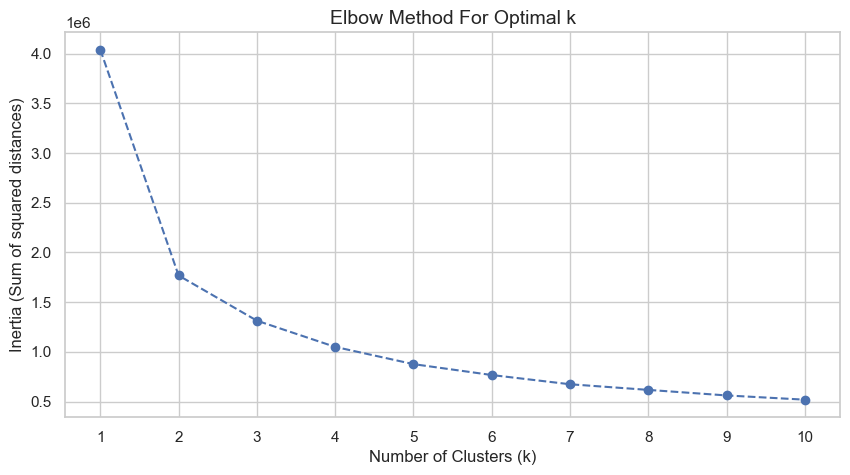

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 데이터 준비 (RFM 지표만 추출)
# 0이 있으면 로그 변환 시 에러(-inf)가 날 수 있으므로 1을 더해주는 log1p를 사용합니다.
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
rfm_log = np.log1p(rfm_features)

# 2. 스케일링 (단위 맞추기)
# Recency(일 단위), Frequency(회 단위), Monetary(금액)를 동일한 영향력으로 맞춥니다.
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)

# 3. 최적의 K 찾기 (Elbow Method)
inertia = []
K_range = range(1, 11)

for k in K_range:
    # n_init='auto'는 최신 sklearn 버전의 경고를 방지합니다.
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_) # inertia: 군집 내 데이터 간의 거리 합

# 4. 엘보우 그래프 시각화
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [88]:
# 1. 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '구매횟수(번)', 'Monetary': '총구매금액($)'})

# 3. 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    구매횟수(번)     총구매금액($)     고객수
Cluster                                            
2         33.449860  20.306623  1223.100428  274281
0        203.238311   6.385883   373.192567  344247
3         44.560006   2.787123   119.925600  187766
1        422.508752   1.374145    61.520354  540226


In [89]:
# 2번(VIP) : 최근에도 왔고, 가장 자주, 많이 구매함. ZEP 라운지 우선 초대 및 한정판 드롭 타겟.
# 0번(잠재적 이탈 단골) :  꽤 자주 이용했었으나 최근 6개월간 방문 뜸함. 리워드 쿠폰으로 재방문 유도가 시급함.
# 3번 (신규 및 유망자) : 구매액은 적지만 최근 활동성이 좋음. 첫 구매 혜택이나 카테고리 확장 유도 필요.
# 1번 (휴먼 고객) :  1년 넘게 방문 안 함. 인원수가 가장 많음. 대규모 리타겟팅 광고나 수신동의 혜택 제안.

## Clouster3 타겟

In [90]:
# 1. Cluster 3 고객 아이디만 추출
c3_users = rfm[rfm['Cluster'] == 3]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c3_data = df[df['customer_id'].isin(c3_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("🛍️ Cluster 3가 가장 선호하는 카테고리 Top 10")
print(c3_data['garment_group_name'].value_counts().head(10))

print("\n👕 Cluster 3가 가장 많이 산 구체적 상품명 Top 10")
print(c3_data['prod_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c3_data['age'].mean()
print(f"\n👥 Cluster 3의 평균 나이: {avg_age:.1f}세")

🛍️ Cluster 3가 가장 선호하는 카테고리 Top 10
garment_group_name
Jersey Fancy         245557
Jersey Basic         182466
Under-, Nightwear    158720
Swimwear             154842
Trousers             132640
Blouses              108321
Dresses Ladies        89126
Knitwear              86891
Accessories           81356
Trousers Denim        51393
Name: count, dtype: int64

👕 Cluster 3가 가장 많이 산 구체적 상품명 Top 10
prod_name
Timeless Midrise Brief         10104
Jade HW Skinny Denim TRS        9964
Tilly (1)                       8628
Cat Tee.                        6672
Tilda tank                      6668
Luna skinny RW                  6168
Simple as That Triangle Top     5688
Shake it in Balconette          5466
Pluto RW slacks (1)             5390
SUPREME RW tights               4793
Name: count, dtype: int64

👥 Cluster 3의 평균 나이: 33.8세
